In [1]:
import pandas as pd
df = pd.read_csv('../data/processed/processed_retail_data.csv', nrows=100)
features = df.drop(columns=['Product_ID'])

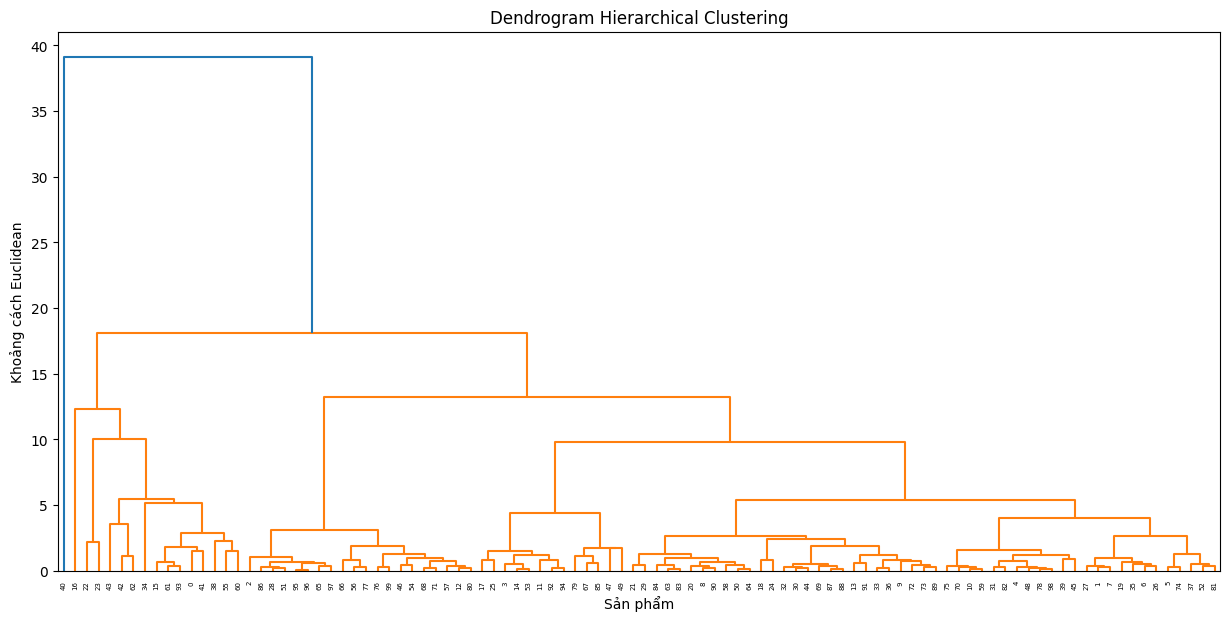

In [2]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
dendrogram = sch.dendrogram(sch.linkage(features, method='ward'))
plt.title('Dendrogram Hierarchical Clustering')
plt.xlabel('Sản phẩm')
plt.ylabel('Khoảng cách Euclidean')
plt.show()

In [3]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df['Cluster'] = model.fit_predict(features)

In [4]:
cluster_analysis = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_analysis)

         total_sales  sale_frequency   revenue  sales_variance  \
Cluster                                                          
0           2.079955        0.488946  0.760746        0.483556   
1          -0.344611       -0.565691 -0.349703       -0.043697   
2          -0.094601       -0.320795 -0.239146       -0.014157   
3           0.689692       -0.587438 -0.332640       27.756946   

         days_since_last_sale  avg_inventory  stock_turnover  
Cluster                                                       
0                   -0.360052       2.160758       -0.179043  
1                    2.180401      -0.319801       -0.206051  
2                   -0.161127      -0.070803       -0.014452  
3                    2.221303       0.621555       -0.159934  


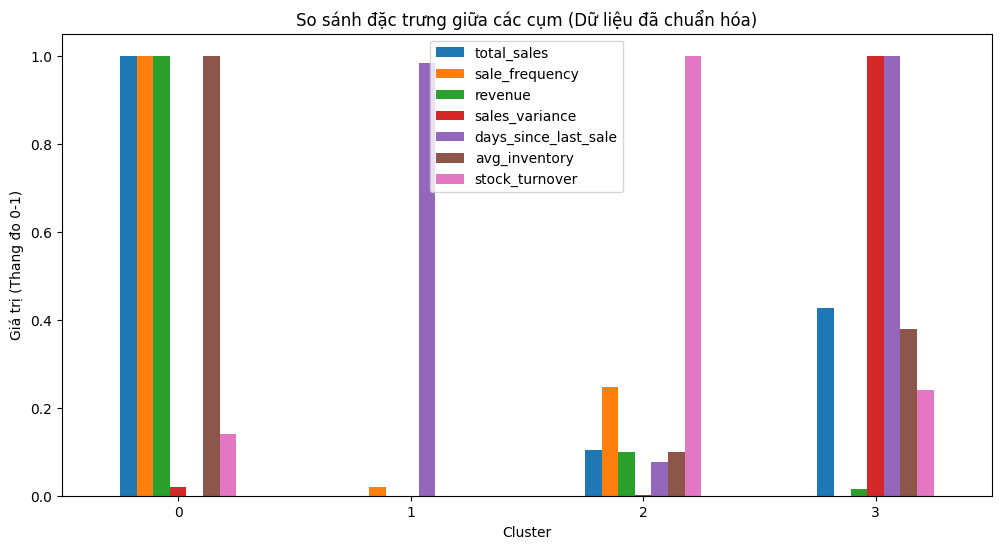

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

# Chuẩn hóa dữ liệu trước khi vẽ
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(cluster_analysis), columns=cluster_analysis.columns, index=cluster_analysis.index)

# Vẽ lại biểu đồ cột với dữ liệu đã chuẩn hóa
df_scaled.plot(kind='bar', figsize=(12, 6))
plt.title('So sánh đặc trưng giữa các cụm (Dữ liệu đã chuẩn hóa)')
plt.ylabel('Giá trị (Thang đo 0-1)')
plt.xticks(rotation=0)
plt.show()

In [6]:
from sklearn.cluster import KMeans

# Xây dựng mô hình K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(features)

# Tính trung bình các cụm KMeans
kmeans_analysis = df.groupby('Cluster_KMeans').mean(numeric_only=True)
print(kmeans_analysis)

                total_sales  sale_frequency   revenue  sales_variance  \
Cluster_KMeans                                                          
0                  2.398626        0.749523  1.093586        0.166717   
1                 -0.019028       -0.278662 -0.213785       -0.000593   
2                  0.689692       -0.587438 -0.332640       27.756946   
3                 -0.220834       -0.535943 -0.342052        0.114772   

                days_since_last_sale  avg_inventory  stock_turnover   Cluster  
Cluster_KMeans                                                                 
0                          -0.540664       2.554955       -0.247314  0.000000  
1                          -0.401655       0.017325       -0.080566  1.892857  
2                           2.221303       0.621555       -0.159934  3.000000  
3                           1.760471      -0.237211       -0.015608  1.312500  


In [7]:
from sklearn.metrics import silhouette_score

# Silhouette Score cho Hierarchical Clustering
h_score = silhouette_score(features, model.labels_)
# Silhouette Score cho K-Means
k_score = silhouette_score(features, df['Cluster_KMeans'])

print(f"Silhouette Score (Hierarchical): {h_score:.3f}")
print(f"Silhouette Score (K-Means): {k_score:.3f}")

Silhouette Score (Hierarchical): 0.353
Silhouette Score (K-Means): 0.363


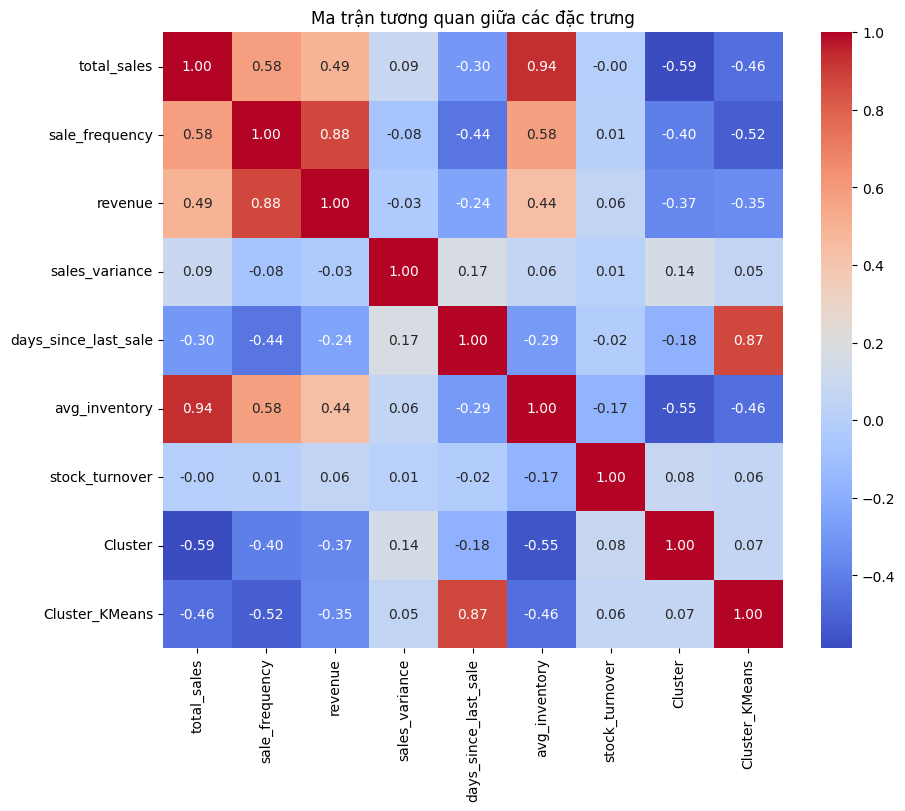

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các đặc trưng')
plt.show()